# <font color=darkcyan>  Expectation Maximization for latent data models </font>

In the case where we are interested in estimating unknown parameters $\theta\in\mathbb{R}^m$ characterizing a model with missing data, the Expectation Maximization (EM) algorithm (Dempster et al. 1977) can be used when the joint distribution of the missing data $Z$ and the observed data $X$ is explicit. For all $\theta\in\mathbb{R}^m$, let $p_{\theta}$ be the probability density function of $(Z,X)$ when the model is parameterized by $\theta$ with respect to a given reference measure $\mu$. The EM algorithm aims at computing iteratively an approximation of the maximum likelihood estimator which maximizes the observed data loglikelihood:

$$
\ell(\theta;X) = \log p_{\theta}(X) =\log \int p_{\theta}(z,X)\mu(\mathrm{d}z)\,.
$$

As this quantity cannot be computed explicitly in general cases, the EM algorithm finds the maximum likelihood estimator by iteratively maximizing the expected complete data loglikelihood.
 
Start with an inital value $\theta^{(0)}$ and let $\theta^{(t)}$ be the estimate at the $t$-th iteration for $t\geqslant 0$, then the next iteration of EM is decomposed into two steps.

1. E-step. Compute the expectation of the complete data loglikelihood, with respect to the conditional distribution of the missing data given the observed data parameterized by $\theta^{(t)}$:

$$
Q(\theta,\theta^{(t)}) =\mathbb{E}_{\theta^{(t)}}\left[\log p_{\theta}(Z,X)|X \right]\,.
$$

2. M step. Determine $\theta^{(t+1)}$ by maximizing the function Q:

$$
\theta^{(t+1)}\in \operatorname*{argmax}_{\theta} Q(\theta,\theta^{(t)})\,.
$$

#### Question 1 
Prove the following crucial property motivates the EM algorithm.  
For all $\theta,\theta^{(t)}$,
    
$$
\ell(X;\theta) - \ell(X;\theta^{(t)}) \geqslant Q(\theta,\theta^{(t)})-Q(\theta^{(t)},\theta^{(t)})\,.
$$

In the following, $Z = (Z_1,\ldots,Z_n)$ and $X = (X_1,\ldots,X_n)$ where $\{(Z_i,X_i)\}_{1\leqslant i\leqslant n}$  are i.i.d. in $\{-1,1\} \times \mathbb{R}^d$. For $k\in\{-1,1\}$, write $\pi_k = \mathbb{P}_\theta(Z_1 = k)$. Assume that, conditionally on the event $\{Z_1 = k\}$, $X_1$ has a Gaussian distribution with mean $\mu_k \in\mathbb{R}^d$ and covariance matrix $\Sigma\in \mathbb{R}^{d\times d}$. In this case, the parameter $\theta=(\pi_1, \mu_1,\mu_{-1}, \Sigma)$ belongs to the set $\Theta= [0,1] \times \mathbb{R}^d \times \mathbb{R}^d \times \mathbb{R}^{d \times d}$. For all $t\geq 0$, the parameter $\theta^{(t)}$ is written
$$
\theta^{(t)} = \left\{\pi^{(t)}_1, \mu^{(t)}_1,\mu^{(t)}_{-1}, \Sigma^{(t)}\right\}\,.
$$

#### Question 2
- Write the complete data loglikelihood
- Let $\theta^{(t)}$ be the current parameter estimate. Compute $\theta\mapsto Q(\theta,\theta^{(t)})$.
- Compute $\theta^{(t+1)} = \mathrm{argmax}_\theta Q(\theta,\theta^{(t)})$. 

Complete data loglikelihood: $$\sum_{i=1}^n log(p_{\theta}(X,Z)) =  \sum_{i=1}^n \left[ log(\pi_Z) + log(\varphi_d(X_i;\mu_{Z_i},\Sigma))\right]$$
Où $N(X|\mu_k, \Sigma)$ est la log-densité de la normal conditionné a Z = k


$$\tau_{ik}^{(t)}
= \mathbb P_{\theta^{(t)}}(Z_i = k \mid X_i)
= \frac{
\pi_k^{(t)} \, \varphi_d(X_i;\mu_k^{(t)},\Sigma^{(t)})
}{
\sum_{j\in\{-1,1\}}
\pi_j^{(t)} \, \varphi_d(X_i;\mu_j^{(t)},\Sigma^{(t)})
}.$$

$$Q(\theta,\theta^{(t)})
= \sum_{i=1}^n \sum_{k\in\{-1,1\}}
\tau_{ik}^{(t)}
\left[
\log \pi_k
+ \log \varphi_d(X_i;\mu_k,\Sigma)
\right].$$

### Actualització dels pesos de mescla


$$
\pi_k^{(t+1)}
= \frac{1}{n} \sum_{i=1}^n \tau_{ik}^{(t)},
\qquad k\in\{-1,1\}.
$$



### Actualització de les mitjanes



$$
\mu_k^{(t+1)}
= \frac{
\sum_{i=1}^n \tau_{ik}^{(t)} X_i
}{
\sum_{i=1}^n \tau_{ik}^{(t)}
},
\qquad k\in\{-1,1\}.
$$



### Actualització de la covariància comuna



$$
\Sigma^{(t+1)}
= \frac{1}{n}
\sum_{i=1}^n \sum_{k\in\{-1,1\}}
\tau_{ik}^{(t)}
\left(
X_i - \mu_k^{(t+1)}
\right)
\left(
X_i - \mu_k^{(t+1)}
\right)^\top.
$$




In [2]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

#### <font color=darkorange>  Simulated data</font>

#### Question 3
- Sample data from a mixture of two Gaussian distributions and display the associated histogram

In [64]:
# number of observations
n_samples = 100

# means and variance to be estimated
mu1, sigma1 = -2, 1.5
mu2, sigma2 = 3, 1

# prior probability of the first cluster/goup 
pi1 = 0.3

def generate_mixture_data(n_samples, mu1, sigma1, mu2, sigma2, pi1):
    U = stats.uniform.rvs(size=n_samples)
    A = stats.norm.rvs(size=n_samples, loc=mu1, scale=sigma1)
    B = stats.norm.rvs(size=n_samples, loc=mu2, scale=sigma2)

    X = np.zeros(n_samples)
    for i in range(n_samples):
        if(U[i] <= pi1):
            X[i] = A[i]
        else:
            X[i] = B[i]
    return X

X = generate_mixture_data(n_samples, mu1, sigma1, mu2, sigma2, pi1)

In [7]:
def Gaussian_pdf(x, mean, variance):
  z = np.exp(-(x - mean)**2/(2*variance))/np.sqrt(2*np.pi*variance)
  return z

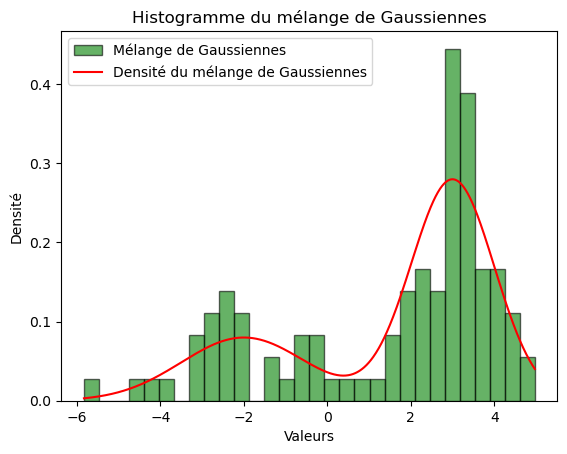

In [8]:
# visualize the training data

densite_melange = pi1 * Gaussian_pdf(np.linspace(X.min(), X.max(),1000), mu1, sigma1**2) + (1 - pi1) * Gaussian_pdf(np.linspace(X.min(), X.max(),1000), mu2, sigma2**2)

fig, ax = plt.subplots()
ax.hist(X, bins=30, density=True, alpha=0.6, color='g', linewidth=1, edgecolor='black', label='Mélange de Gaussiennes')
ax.plot(np.linspace(X.min(), X.max(),1000), densite_melange, color='red', label='Densité du mélange de Gaussiennes')
ax.set_title('Histogramme du mélange de Gaussiennes')
ax.set_xlabel('Valeurs')
ax.set_ylabel('Densité')
ax.legend()
plt.show()
# A compléter

#### <font color=darkorange>  EM algorithm</font>

In [ ]:
# plot estimated density - plot the density of a mixture of two Gaussian distributions


#### Question 5
 - Compute $\omega_t^i = \mathbb{P}_{\theta^{(t)}}(Z_i=1|X_i)$.
 - Write the loop of the EM algorithm.
 - Run the algorithm and display the loglikelihood and the estimates along iterations.



$$\omega_{t}^{i}
= \mathbb P_{\theta^{(t)}}(Z_i = 1 \mid X_i)
= \frac{
\pi_1^{(t)} \, \varphi_d(X_i;\mu_k^{(t)},\Sigma^{(t)})
}{
\sum_{j\in\{-1,1\}}
\pi_j^{(t)} \, \varphi_d(X_i;\mu_j^{(t)},\Sigma^{(t)})
}.$$

In [9]:
#Pour d=1
def EM_loop(n_it, n, weights, means, variances, X):
    omega = np.zeros(n)
    Var, Mean, W = np.zeros((n_it, n_clust)), np.zeros((n_it, n_clust)), np.zeros((n_it, n_clust))
    Var[0] = variances
    Mean[0] = means
    W[0] = weights
    for i in range(n_it):
        #on calcule les poids de chaque composante pour chaque point de données
        omega = weights[1]*stats.norm.pdf(X, means[1], scale=np.sqrt(variances[1])) / (weights[0]*stats.norm.pdf(X, means[0], scale=np.sqrt(variances[0])) + weights[1]*stats.norm.pdf(X, means[1], scale=np.sqrt(variances[1])))
        #Ça c'est pour Z=1, pour Z=-1, on fait 1-omega
        #on met à jour les poids, les moyennes et les variances
        weights[0] = np.mean(1-omega)
        weights[1] = np.mean(omega)
        W[i] = weights

        means[0] = np.sum((1-omega)*X) / np.sum(1-omega)
        means[1] = np.sum(omega*X) / np.sum(omega)
        Mean[i] = means

        variances[0] = np.sum((1-omega)*(X-means[0])**2) / np.sum(1-omega)
        variances[1] = np.sum(omega*(X-means[1])**2) / np.sum(omega)
        Var[i] = variances

    return W, Mean, Var

        
n_clust = 2
weights = np.ones((n_clust)) / n_clust
means = [0, 1]
variances = [0.5, 2]



In [10]:
# number of iterations of the EM algorithm
n_it = 100

In [11]:
W, Mean, Var = EM_loop(n_it, n_samples, weights, means, variances, X)

$$\sum_{i=1}^n log(p_{\theta}(X,Z)) =  \sum_{i=1}^n \left[ log(\pi_{Z_i}) + log(\varphi_d(X_i;\mu_{Z_i},\Sigma))\right]$$

On n'a pas les données pour calculer cette vraisemblance, mais on a:

$$log(\prod_{i=1}^n p_\theta(X_i)) = \sum_{i=1}^n log(\pi_1\varphi_d(X_i;\mu_{1},\sigma_{1}) + (1-\pi_1)\varphi_d(X_i;\mu_{-1},\sigma_{-1}))

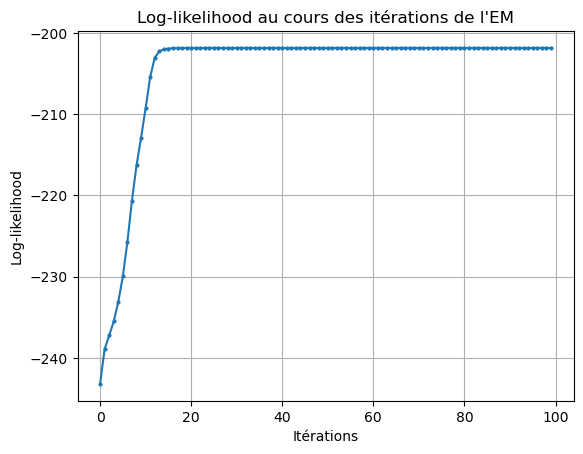

In [12]:
#On montre l'évolution de la loglikelihood à chaque itération
loglikelihood = np.zeros(n_it)
for i in range(n_it):
    norm1=stats.norm.pdf(X, Mean[i][0], scale=np.sqrt(Var[i][0]))
    norm2=stats.norm.pdf(X, Mean[i][1], scale=np.sqrt(Var[i][1]))
    l = np.log(W[i][0]*norm1 + (1-W[i][0])*norm2)
    loglikelihood[i] = np.sum(l)

# plot loglikelihood along iterations
plt.figure()
plt.plot(range(n_it), loglikelihood, marker='o', markersize=2, label='Log-likelihood')
plt.title('Log-likelihood au cours des itérations de l\'EM')
plt.xlabel('Itérations')
plt.ylabel('Log-likelihood')
plt.grid()
plt.show()


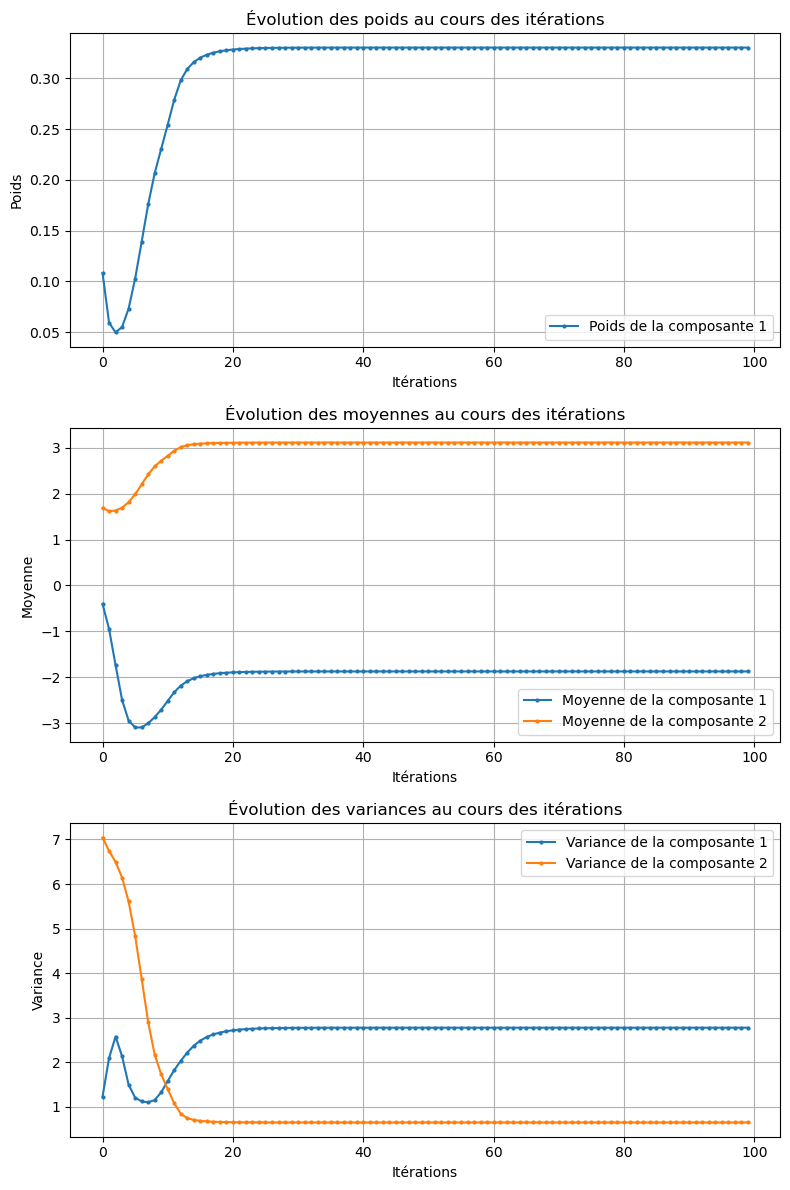

In [13]:
#On décrit l'evolution des paramètres au cours des itérations
fig, ax = plt.subplots(3, 1, figsize=(8, 12))
# plot parameters along iterations
ax[0].plot(range(n_it), W[:, 0], marker='o', markersize=2, label='Poids de la composante 1')
ax[0].set_xlabel('Itérations')
ax[0].set_ylabel('Poids')
ax[0].set_title('Évolution des poids au cours des itérations')
ax[0].legend()
ax[0].grid()
ax[1].plot(range(n_it), Mean[:, 0], marker='o', markersize=2, label='Moyenne de la composante 1')
ax[1].plot(range(n_it), Mean[:, 1], marker='o', markersize=2, label='Moyenne de la composante 2')
ax[1].set_xlabel('Itérations')
ax[1].set_ylabel('Moyenne')
ax[1].set_title('Évolution des moyennes au cours des itérations')
ax[1].legend()
ax[1].grid()
ax[2].plot(range(n_it), Var[:, 0], marker='o', markersize=2, label='Variance de la composante 1')
ax[2].plot(range(n_it), Var[:, 1], marker='o', markersize=2, label='Variance de la composante 2')
ax[2].set_xlabel('Itérations')
ax[2].set_ylabel('Variance')
ax[2].set_title('Évolution des variances au cours des itérations')
ax[2].legend()
ax[2].grid()
plt.tight_layout()
plt.show()


#### Question 6

- Explore the sensitivity of the algorithm with respect to i) the initial estimates, ii) the number of iterations, iii) the number of observations and iv) the number of clusters. 

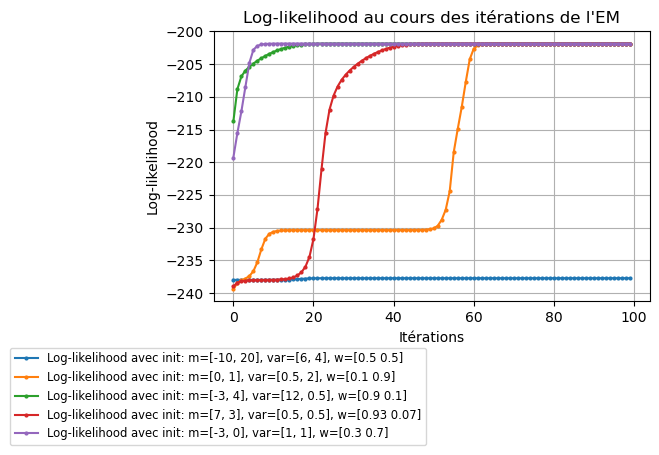

In [63]:
#On commence en voir comment tout change en changeant les paramètres initiaux
#avant on avait : n_clust = 2 weights = np.ones((n_clust)) / n_clust, means = [0, 1],variances = [0.5, 2]
#on fait différents choix de paramètres initiaux et on observe l'évolution des paramètres et de la loglikelihood au cours des itérations

means_init = [[-10, 20], [0, 1], [-3, 4], [7, 3], [-3, 0]]
variances_init = [[6, 4], [0.5, 2], [12, 0.5], [0.5, 0.5], [1, 1]]
weights_init = [np.array([0.5, 0.5]), np.array([0.1, 0.9]), np.array([0.9, 0.1]), np.array([0.93, 0.07]), np.array([0.3, 0.7])]

plt.figure()
for i in range(len(means_init)):
    wini = weights_init[i].copy()
    mini = means_init[i].copy()
    vari = variances_init[i].copy()
    W, Mean, Var = EM_loop(n_it, n_samples, wini, mini, vari, X)
    loglikelihood = np.zeros(n_it)
    for j in range(n_it):
        norm1=stats.norm.pdf(X, Mean[j][0], scale=np.sqrt(Var[j][0]))
        norm2=stats.norm.pdf(X, Mean[j][1], scale=np.sqrt(Var[j][1]))
        l = np.log(W[j][0]*norm1 + (1-W[j][0])*norm2)
        loglikelihood[j] = np.sum(l)
    
    # plot loglikelihood along iterations
    plt.plot(range(n_it), loglikelihood, marker='o', markersize=2, label=f'Log-likelihood avec init: m={means_init[i]}, var={variances_init[i]}, w={weights_init[i]}')
    plt.title(f'Log-likelihood au cours des itérations de l\'EM')

plt.xlabel('Itérations')
plt.ylabel('Log-likelihood')
plt.legend(loc='best', fontsize='small', bbox_to_anchor=(0.5, -0.15))
plt.grid()
plt.tight_layout()
plt.show()

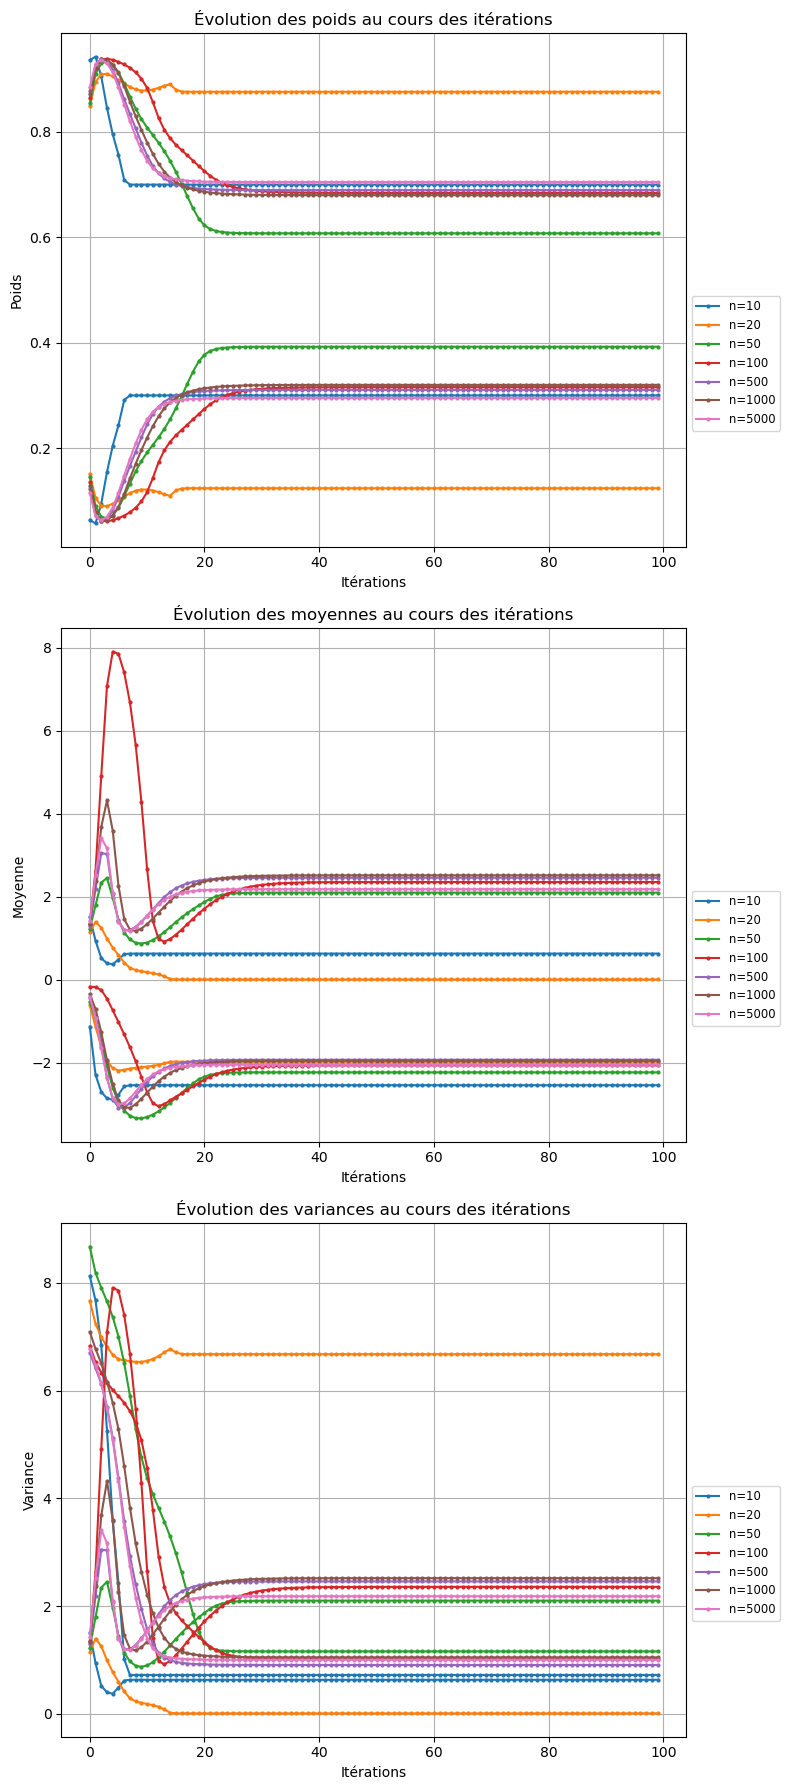

In [79]:
#maintenant on observe ce qu'il se passe si on a plus ou moins d'observations
weights = np.ones((n_clust)) / n_clust
means = [0, 1]
variances = [0.5, 2]

fig, ax = plt.subplots(3,1,figsize=(8, 18))
n_samples_list = [10, 20, 50, 100, 500, 1000, 5000]
loglikelihood_list = []
for n_samples in n_samples_list:
    X = generate_mixture_data(n_samples, mu1, sigma1, mu2, sigma2, pi1)
    W, Mean, Var = EM_loop(n_it, n_samples, weights.copy(), means.copy(), variances.copy(), X)
    line, = ax[0].plot(range(n_it), W[:, 0], marker='o', markersize=2, label=f"n={n_samples}")
    color = line.get_color()
    ax[0].plot(range(n_it), W[:, 1], marker='o', markersize=2, color=color)
    ax[1].plot(range(n_it), Mean[:, 0], marker='o', markersize=2, label=f"n={n_samples}", color=color)
    ax[1].plot(range(n_it), Var[:, 0], marker='o', markersize=2, color=color)
    ax[2].plot(range(n_it), Var[:, 0], marker='o', markersize=2, label=f"n={n_samples}", color=color)
    ax[2].plot(range(n_it), Var[:, 1], marker='o', markersize=2, color=color)

ylabels = ['Poids', 'Moyenne', 'Variance']
titles = [
    "Évolution des poids au cours des itérations",
    "Évolution des moyennes au cours des itérations",
    "Évolution des variances au cours des itérations"
]

# Iteramos sobre los ejes y sus textos correspondientes
for i, a in enumerate(ax):
    a.set_xlabel('Itérations')
    a.set_ylabel(ylabels[i])
    a.set_title(titles[i])
    a.legend(fontsize='small', bbox_to_anchor=(1, 0.5))
    a.grid()

plt.tight_layout()
plt.show()

